# Le centre et la périphérie des grandes villes se rapprochent-ils ?

**Question du projet** : comment les prix de l'immobilier ont-ils évolué dans les grandes villes
françaises depuis cinq ans, et où l'écart entre le centre et la périphérie se creuse-t-il le plus ?

Ce notebook raconte l'analyse de bout en bout. Toute la logique (téléchargement, nettoyage,
agrégations) vit dans le dossier `src/` du dépôt ; ici, on l'appelle et on commente.

- Dashboard interactif : [analyse-immobilier-dvf.streamlit.app](https://analyse-immobilier-dvf.streamlit.app)
- Méthode complète et limites : [README](https://github.com/eliasbabouche/analyse-immobilier-dvf)

In [1]:
import sys
from pathlib import Path

# Dans Google Colab, le notebook arrive seul : on récupère le reste du projet.
if "google.colab" in sys.modules and not Path("src").exists():
    !git clone -q https://github.com/eliasbabouche/analyse-immobilier-dvf.git
    %cd analyse-immobilier-dvf

# Lancé depuis notebooks/, la racine du projet est le dossier parent.
RACINE = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RACINE))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

from src import config, nettoyage, telecharger_donnees
from src import graphiques as g

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})
EUROS = FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))


def lire(nom):
    return pd.read_csv(
        config.DONNEES_AGREGE / f"{nom}.csv",
        sep=config.SEPARATEUR_EXPORT,
        encoding=config.ENCODAGE_EXPORT,
        dtype={"code_commune": str},
    )


entonnoir = lire("entonnoir")
prix_zones = lire("prix_ville_zone")
evolution = lire("evolution_ecart")

## 1. Des lignes brutes aux ventes analysables

Les données DVF recensent toutes les ventes immobilières de France. Pour les dix métropoles
étudiées, sur 2021-2025, on part de 1,4 million de ventes. Chaque étape du nettoyage est une
règle explicite, testée dans `tests/test_nettoyage.py` :

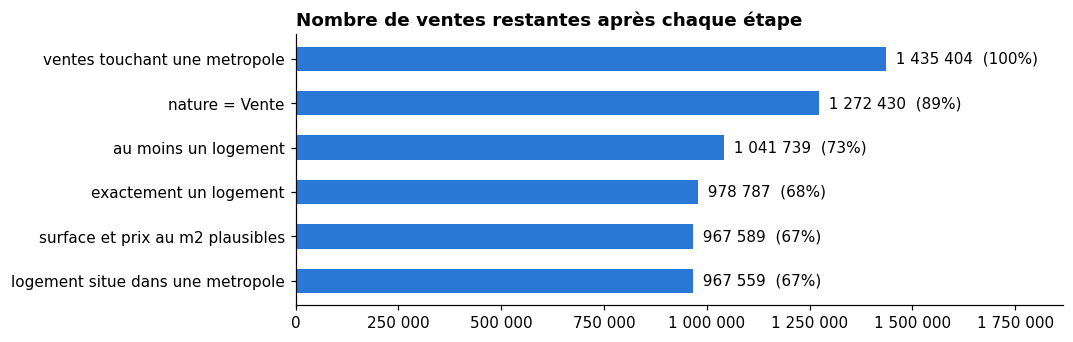

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(entonnoir["etape"], entonnoir["nb_ventes"], color=g.BLEU, height=0.55)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(EUROS)
depart = entonnoir["nb_ventes"].iloc[0]
for i, n in enumerate(entonnoir["nb_ventes"]):
    ax.text(n, i, f"  {n:,}".replace(",", " ") + f"  ({n / depart:.0%})", va="center")
ax.set_xlim(0, depart * 1.3)
ax.set_title("Nombre de ventes restantes après chaque étape")
plt.show()

- **−18 % à l'étape « au moins un logement »** : parkings seuls, terrains, commerces. Hors sujet.
- **−6 % à l'étape « exactement un logement »** : les ventes de plusieurs logements, dont le prix
  global ne peut pas être réparti. C'est le vrai coût de la méthode, et la section suivante
  explique pourquoi il est indispensable.
- **−1 % pour les aberrations** : prix au m² hors de [500 €, 30 000 €] ou surface < 9 m².

## 2. Le piège des ventes multi-lots

Dans le DVF, une vente de plusieurs biens (un appartement et sa cave, par exemple) apparaît sur
plusieurs lignes, **avec le prix total répété sur chacune**. Démonstration sur la
Loire-Atlantique en 2025 (fichier de 2 Mo, téléchargé s'il est absent) :

In [11]:
config.creer_dossiers()
fichier = telecharger_donnees.chemin_dvf(2025, "44")
telecharger_donnees.telecharger(telecharger_donnees.url_dvf(2025, "44"), fichier)
brut = nettoyage.charger(fichier)

# Une vente typique : un appartement vendu avec deux dependances (cave, parking)
types_par_vente = brut.groupby("id_mutation")["type_local"].agg(lambda t: sorted(t, key=str))
id_exemple = types_par_vente[
    types_par_vente.map(lambda t: t == ["Appartement", "Dépendance", "Dépendance"])
].index[0]
colonnes = ["id_mutation", "valeur_fonciere", "type_local", "surface_reelle_bati"]
brut.loc[brut["id_mutation"] == id_exemple, colonnes]

,id_mutation,valeur_fonciere,type_local,surface_reelle_bati
12,2025-563771,114000.0,Dépendance,NaN
13,2025-563771,114000.0,Dépendance,NaN
14,2025-563771,114000.0,Appartement,35.0


Une seule vente, plusieurs lignes, le même prix partout. Comparons deux calculs du prix au m²
des appartements nantais :

- **naïf** : chaque ligne d'appartement, prix ÷ surface (ce que l'on fait sans connaître le piège) ;
- **correct** : la chaîne de `src/nettoyage.py`, une ligne par vente d'un seul logement.

In [5]:
NANTES = "44109"

# Calcul naif, ecrit ici volontairement : c'est la methode a ne pas suivre.
naif = brut[
    (brut["code_commune"] == NANTES)
    & (brut["type_local"] == "Appartement")
    & (brut["surface_reelle_bati"] > 0)
]
naif = naif.assign(prix_m2=naif["valeur_fonciere"] / naif["surface_reelle_bati"])

# Calcul correct : les fonctions du projet
correct = brut
for etape in [nettoyage.garder_ventes, nettoyage.garder_ventes_avec_logement,
              nettoyage.garder_ventes_un_logement, nettoyage.ecarter_aberrations]:
    correct = etape(correct)
correct = correct[(correct["code_commune"] == NANTES) & (correct["type_local"] == "Appartement")]

comparaison = pd.DataFrame({
    "naïf (par ligne)": [naif["prix_m2"].mean(), naif["prix_m2"].median(), naif["prix_m2"].max()],
    "correct (par vente)": [correct["prix_m2"].mean(), correct["prix_m2"].median(),
                            correct["prix_m2"].max()],
}, index=["moyenne €/m²", "médiane €/m²", "maximum €/m²"]).round(0)
comparaison["écart"] = (comparaison.iloc[:, 0] / comparaison.iloc[:, 1] - 1).map("{:+.0%}".format)
comparaison

,naïf (par ligne),correct (par vente),écart
moyenne €/m²,9555.0,3450.0,+177%
médiane €/m²,3516.0,3390.0,+4%
maximum €/m²,566250.0,11500.0,+4824%


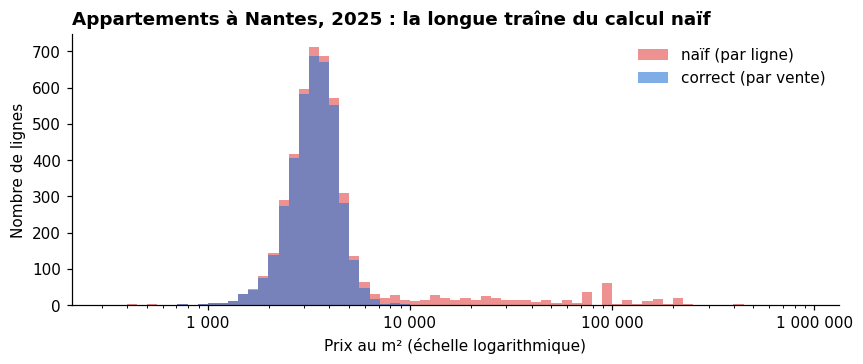

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.2))
bornes = [10 ** (i / 20) for i in range(50, 120)]
ax.hist(naif["prix_m2"], bins=bornes, color=g.ROUGE, alpha=0.6, label="naïf (par ligne)")
ax.hist(correct["prix_m2"], bins=bornes, color=g.BLEU, alpha=0.6, label="correct (par vente)")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(EUROS)
ax.set_xlabel("Prix au m² (échelle logarithmique)")
ax.set_ylabel("Nombre de lignes")
ax.set_title("Appartements à Nantes, 2025 : la longue traîne du calcul naïf")
ax.legend(frameon=False)
plt.show()

**Lecture.** Le calcul naïf fabrique une traîne de prix absurdes, jusqu'à plusieurs centaines de
milliers d'euros le m² : ce sont des prix de ventes entières divisés par la surface d'un seul
logement. La **moyenne** est gonflée de plus de 150 %. La **médiane**, elle, bouge peu : d'où les
deux protections du projet, raisonner par vente **et** travailler sur la médiane.

## 3. Comparer à type de bien égal

Le centre et la périphérie ne vendent pas les mêmes biens :

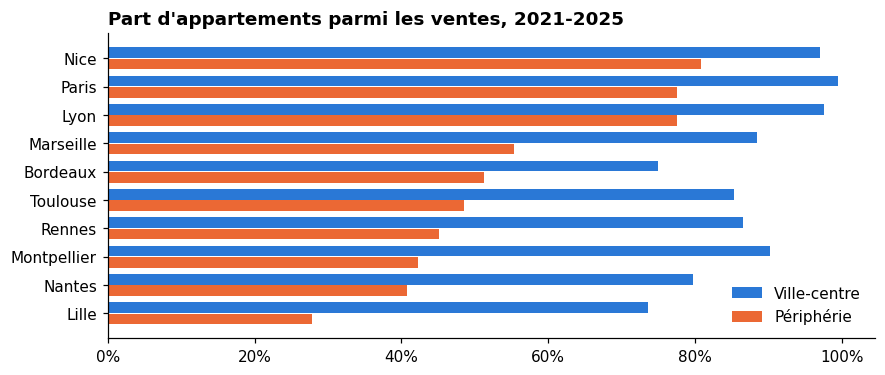

In [7]:
volumes = prix_zones.pivot_table(index=["ville", "zone"], columns="type_local",
                                 values="nb_ventes", aggfunc="sum")
part = (volumes["Appartement"] / volumes.sum(axis=1)).unstack("zone")
part = part.rename(columns=g.NOM_ZONE).sort_values("Périphérie")

fig, ax = plt.subplots(figsize=(9, 3.6))
y = range(len(part))
ax.barh([i + 0.2 for i in y], part["Ville-centre"], height=0.38, color=g.BLEU, label="Ville-centre")
ax.barh([i - 0.2 for i in y], part["Périphérie"], height=0.38, color=g.ORANGE, label="Périphérie")
ax.set_yticks(list(y), part.index)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Part d'appartements parmi les ventes, 2021-2025")
ax.legend(frameon=False, loc="lower right")
plt.show()

À Nantes, 80 % des ventes du centre sont des appartements, contre 41 % en périphérie. Comparer
« tous biens » mélangerait l'effet du lieu et l'effet du type de bien (**effet de composition**).
Toutes les comparaisons qui suivent sont donc faites **à type de bien égal**.

## 4. Résultats : l'écart se resserre

On mesure l'écart par le **ratio** prix médian au m² du centre ÷ celui de la périphérie
(1,30 = centre 30 % plus cher), comparable d'une ville à l'autre quel que soit le niveau des prix.
La variation compare la distance du ratio à 1 entre 2021 et 2025 : négative, l'écart se resserre.

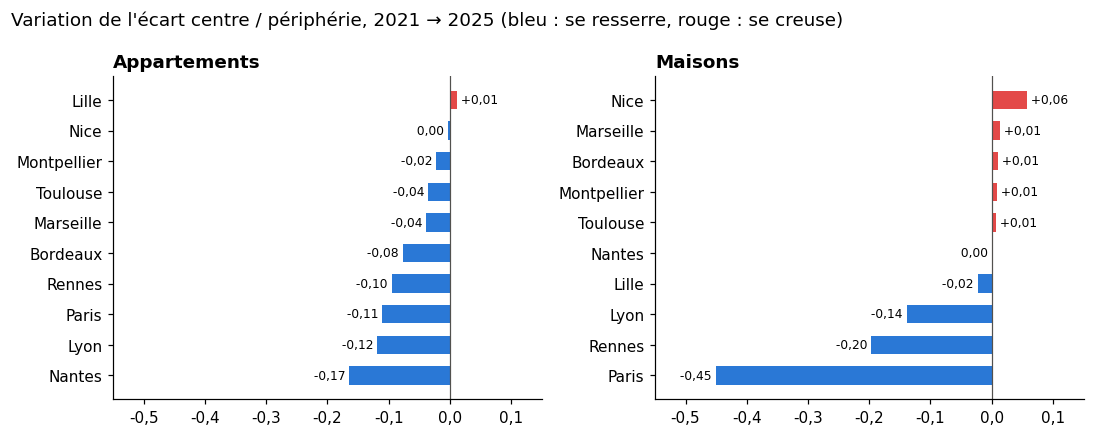

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, type_local in zip(axes, ["Appartement", "Maison"]):
    lignes = evolution[evolution["type_local"] == type_local].sort_values("variation_ecart")
    couleurs = [g.ROUGE if v > 0 else g.BLEU for v in lignes["variation_ecart"]]
    ax.barh(lignes["ville"], lignes["variation_ecart"], color=couleurs, height=0.6)
    for ville, v in zip(lignes["ville"], lignes["variation_ecart"]):
        ax.text(v, ville, f" {g.variation_lisible(v)} ", va="center",
                ha="left" if v > 0 else "right", fontsize=8)
    ax.axvline(0, color=g.TEXTE_SECONDAIRE, linewidth=0.8)
    ax.set_title(f"{type_local}s")
    ax.set_xlim(-0.55, 0.15)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}".replace(".", ",")))
fig.suptitle("Variation de l'écart centre / périphérie, 2021 → 2025 "
             "(bleu : se resserre, rouge : se creuse)", x=0.01, ha="left")
plt.tight_layout()
plt.show()

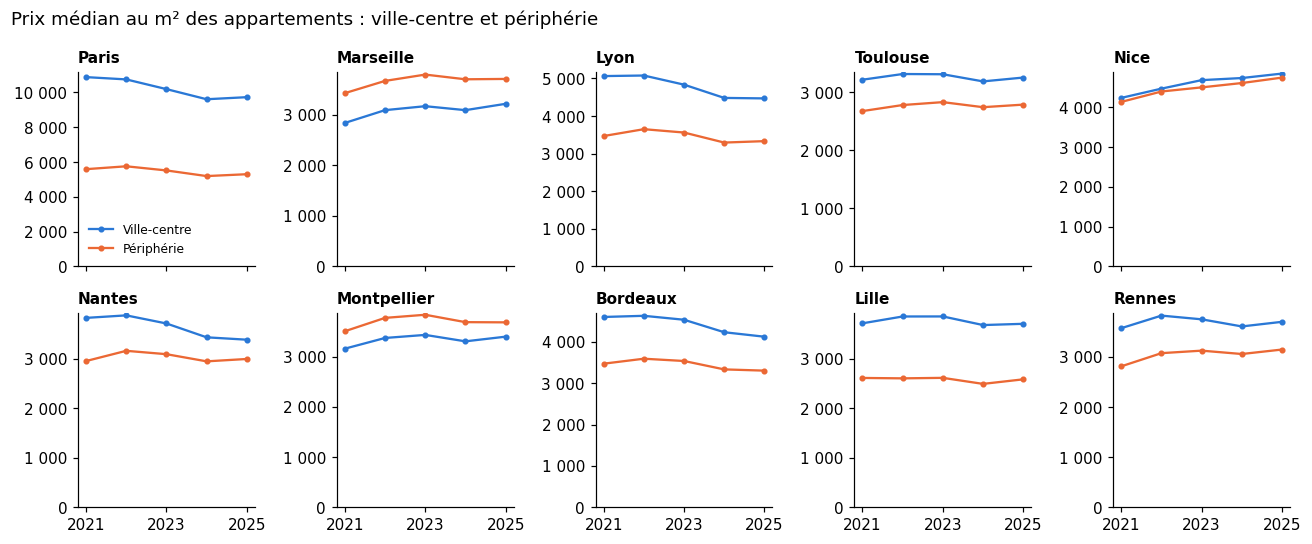

In [9]:
appartements = prix_zones[prix_zones["type_local"] == "Appartement"]
fig, axes = plt.subplots(2, 5, figsize=(12, 5), sharex=True)
for ax, ville in zip(axes.flat, config.VILLES):
    for zone, groupe in appartements[appartements["ville"] == ville].groupby("zone"):
        ax.plot(groupe["annee"], groupe["prix_m2_median"], marker="o", markersize=3,
                color=g.COULEUR_ZONE[zone], label=g.NOM_ZONE[zone])
    ax.set_title(ville, fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(EUROS)
    ax.set_xticks([2021, 2023, 2025])
axes.flat[0].legend(frameon=False, fontsize=8)
fig.suptitle("Prix médian au m² des appartements : ville-centre et périphérie", x=0.01, ha="left")
plt.tight_layout()
plt.show()

## Conclusion

- **Appartements** : l'écart entre le centre et la périphérie **se resserre dans 9 villes sur 10**.
  Le schéma dominant : le centre baisse plus que la périphérie (Nantes −11,5 % au centre, +1,4 %
  en périphérie ; Lyon, Paris, Bordeaux dans le même sens). Seule Lille voit l'écart se creuser,
  très légèrement.
- **Maisons** : résultat plus contrasté, avec un fort resserrement à Paris, Rennes et Lyon, mais un
  léger creusement à Nice, Marseille ou Bordeaux.
- À Marseille et Montpellier, la périphérie (Aix-en-Provence, Cassis…) est plus chère que le centre.

L'hypothèse de départ, un écart qui se creuse, n'est donc pas confirmée : sur la période, c'est le
mouvement inverse qui domine. Explication plausible, non démontrée ici : la hausse des taux à
partir de 2022 a davantage pesé sur les centres, déjà les plus chers.

**Limites** (détaillées dans le README) : ventes de plusieurs logements écartées, neuf exclu,
Strasbourg absente du DVF, comparaison à type de bien égal mais pas à taille égale, périphérie
définie par la métropole administrative.